# **Введение**

В работе рассматривается задача прогнозирования стоимости жилья в Калифорнии на основе набора данных **California Housing Prices**. Для решения задачи используется линейная регрессия и её регуляризованные варианты: Ridge и Lasso.

Перед построением моделей выполняется анализ данных, обработка пропусков, кодирование категориальных признаков, исследование корреляций и проверка мультиколлинеарности с помощью VIF.

Для оценки качества моделей используются следующие метрики:

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2}$$

**RMSE** показывает среднюю величину ошибки прогноза в тех же единицах, что и целевая переменная. Чем меньше значение, тем точнее модель.

$$R^2 = 1-\frac{\sum(y_i-\hat{y_i})^2}{\sum(y_i-\bar y)^2}$$

**R²** показывает, какую долю изменения целевой переменной объясняет модель. Значение ближе к 1 означает лучшее описание данных.

$$MAPE = \frac{100}{n}\sum\left|\frac{y_i-\hat{y_i}}{y_i}\right|$$

**MAPE** отражает среднюю относительную ошибку прогноза в процентах.

До применения PCA проверяется гипотеза: наличие мультиколлинеарности может ухудшать устойчивость коэффициентов линейных моделей. После PCA проверяется гипотеза: переход к главным компонентам может снизить влияние коррелированных признаков, однако за счёт потери части информации.

# **Описание датасета**

In [2]:
# Импорт необходимых библиотек

import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета

df = pd.read_csv('/content/housing.csv')

df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Подготовка окружения

В этой ячейке импортируются библиотеки для анализа данных, визуализации и построения моделей машинного обучения.

Используются `pandas` и `numpy` для обработки данных, `matplotlib` и `seaborn` для графиков, `sklearn` для моделей и метрик, а `statsmodels` используется для расчёта VIF.

Этот набор инструментов покрывает все этапы исследования: от анализа датасета до сравнения моделей.

In [3]:
df.shape

(20640, 10)

### Размер исходного датасета

Полученная форма таблицы показывает количество объектов и признаков в исходном наборе данных.

Это позволяет определить масштаб задачи перед началом обработки. Датасет содержит информацию о районах Калифорнии и используется для прогнозирования `median_house_value`.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


### Информация о структуре данных

Метод `info()` позволяет проверить типы данных и наличие пропусков.

Особое внимание уделяется признаку `total_bedrooms`, так как именно в нём присутствуют пропущенные значения, которые необходимо обработать перед обучением моделей.

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Описательная статистика

Метод `describe()` показывает основные статистические характеристики числовых признаков: среднее значение, стандартное отклонение, минимум и квартили.

Эти показатели используются для оценки диапазонов признаков и выявления возможных выбросов.

In [6]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


### Анализ пропусков

Подсчёт пропущенных значений необходим перед построением моделей.

Пропуски в `total_bedrooms` будут заменены медианой, так как медиана менее чувствительна к выбросам, чем среднее значение, и лучше сохраняет типичное значение признака.

In [7]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


В рамках лабораторной работы используется датасет California Housing Prices, размещённый на платформе Kaggle. Данный набор данных содержит информацию о жилых районах штата Калифорния и используется для решения задачи регрессии — прогнозирования медианной стоимости жилья.

Исходный набор содержит 20640 объектов и 10 признаков. Целевой переменной является показатель median_house_value, который отражает медианную стоимость жилья в определённом районе.

Датасет включает как числовые, так и категориальные признаки. К числовым относятся географические координаты района, возраст домов, количество комнат, количество спален, население, число домохозяйств и средний доход жителей. Категориальный признак ocean_proximity характеризует расположение района относительно океана.

В ходе первичного анализа было установлено, что большинство признаков представлены в числовом формате float64. Единственным категориальным признаком является ocean_proximity, содержащий пять возможных значений: <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY и ISLAND.

Также была проведена проверка наличия пропущенных значений. Было обнаружено 207 пропусков в признаке total_bedrooms, что составляет около 1% от общего количества объектов. На этапе подготовки данных данные пропуски будут обработаны с использованием медианного заполнения.

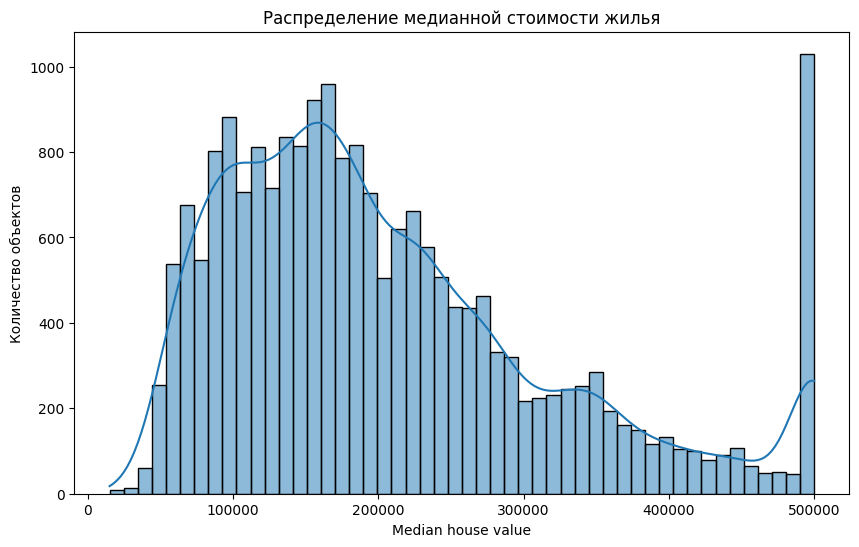

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['median_house_value'],
    bins=50,
    kde=True
)

plt.title('Распределение медианной стоимости жилья')
plt.xlabel('Median house value')
plt.ylabel('Количество объектов')

plt.show()

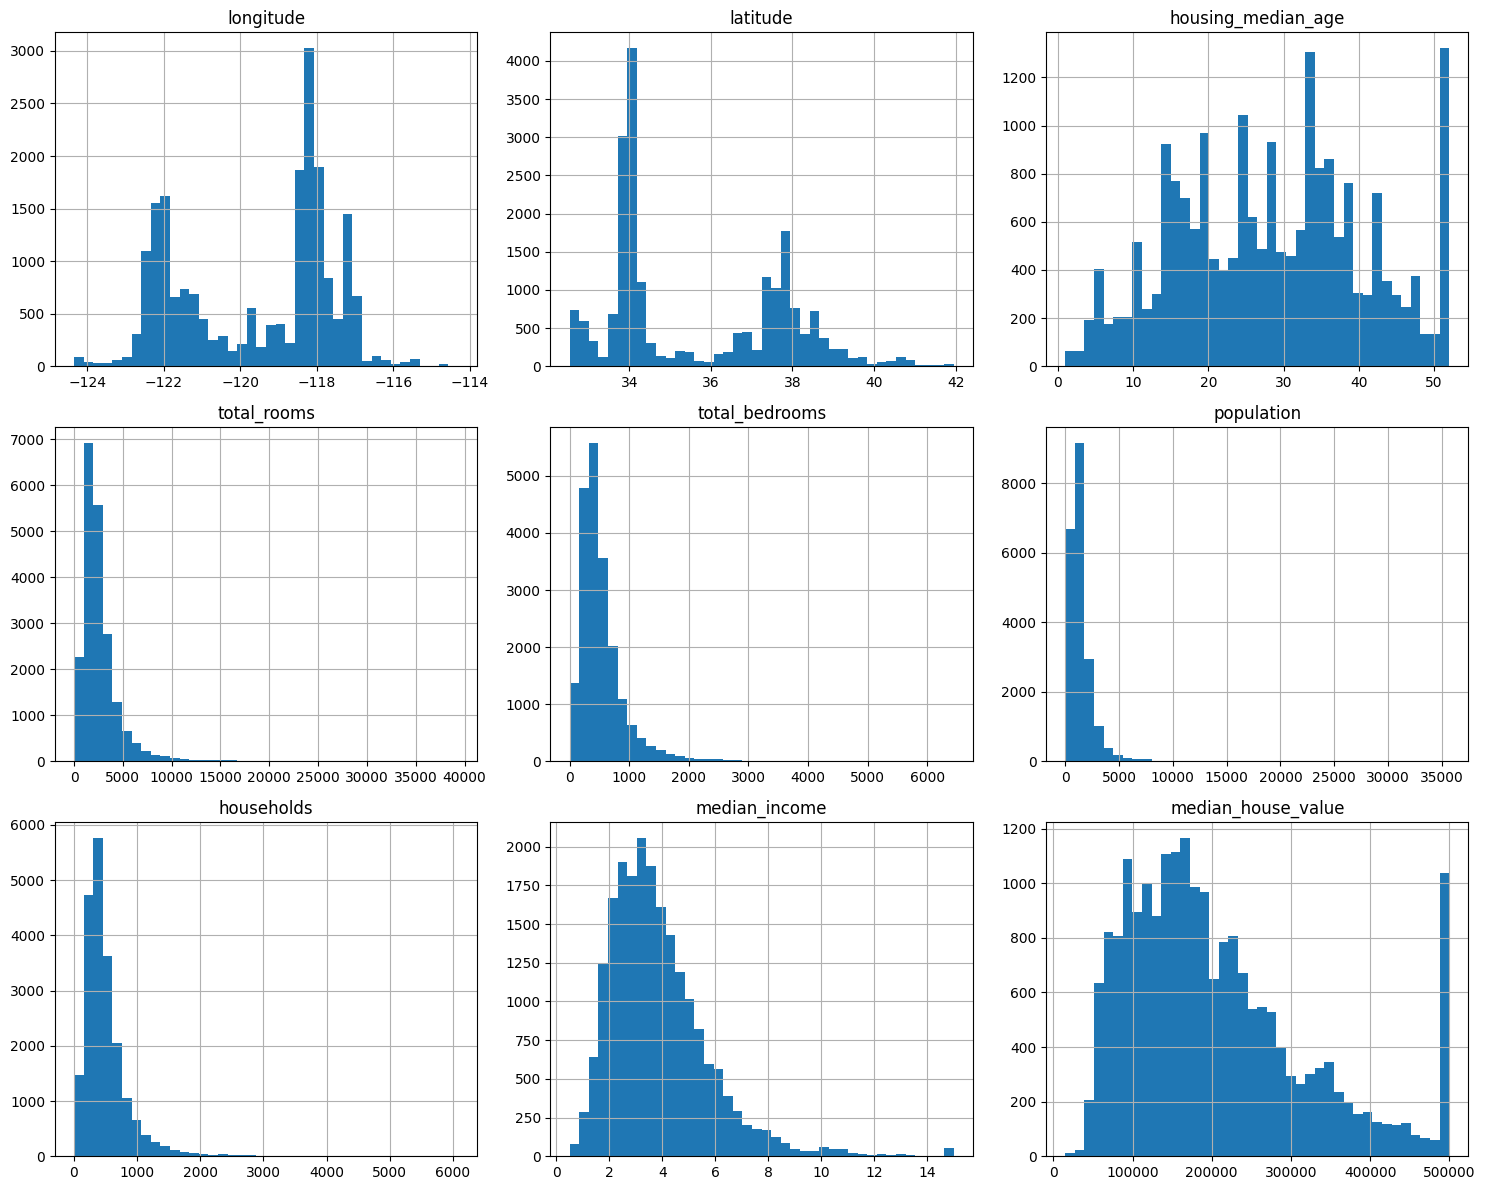

In [9]:
numeric_features = df.select_dtypes(
    include=['float64']
).columns


df[numeric_features].hist(
    figsize=(15,12),
    bins=40
)

plt.tight_layout()
plt.show()

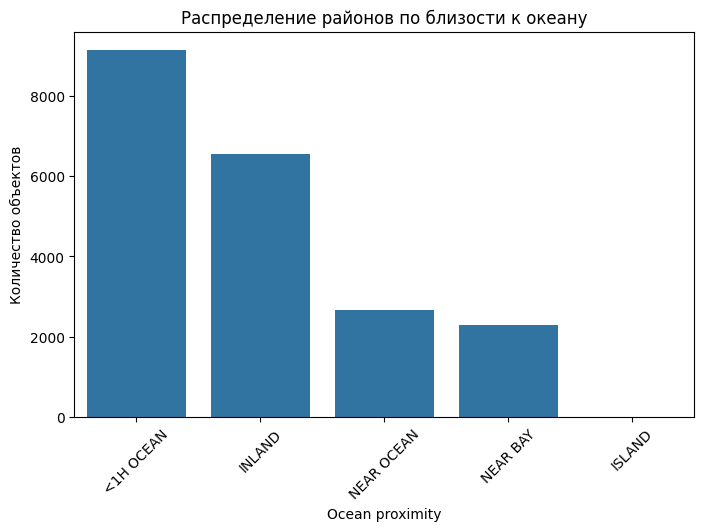

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='ocean_proximity',
    order=df['ocean_proximity'].value_counts().index
)

plt.title('Распределение районов по близости к океану')
plt.xlabel('Ocean proximity')
plt.ylabel('Количество объектов')

plt.xticks(rotation=45)

plt.show()

### Анализ распределения признаков


Для исследования структуры данных были построены графики распределения числовых признаков и целевой переменной.

Распределение целевой переменной median_house_value является асимметричным. Большая часть значений находится в диапазоне от 50000 до 300000 долларов. Наличие выраженного пика около значения 500000 связано с ограничением максимальной стоимости жилья в исходном наборе данных.

Числовые признаки, связанные с количеством комнат, спален, населения и домохозяйств, имеют правостороннее распределение. Это означает наличие большого количества объектов со средними значениями признаков и небольшого количества районов с существенно большими значениями. Такие особенности необходимо учитывать при дальнейшей обработке данных.

Признаки total_rooms, total_bedrooms, population и households имеют схожие распределения, что может указывать на наличие корреляционной зависимости между ними. В дальнейшем для оценки мультиколлинеарности будет построена корреляционная матрица и рассчитан коэффициент VIF.

Категориальный признак ocean_proximity содержит пять классов. Наибольшее количество объектов относится к категориям <1H OCEAN и INLAND, тогда как категория ISLAND представлена только пятью наблюдениями.

In [11]:
# Кодирование категориального признака для анализа корреляции

df_corr = df.copy()

df_corr = pd.get_dummies(
    df_corr,
    columns=['ocean_proximity'],
    drop_first=True
)

df_corr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


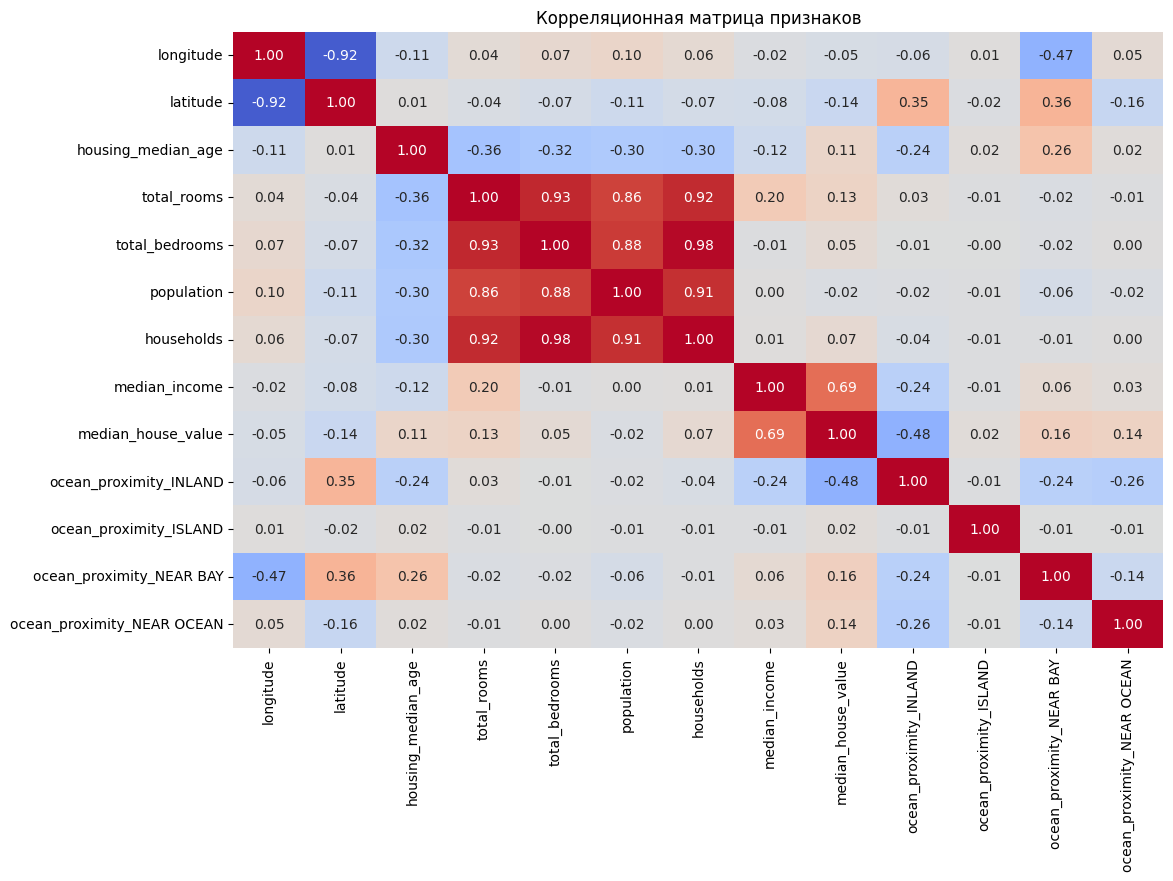

In [12]:
plt.figure(figsize=(12,8))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    cbar=False
)

plt.title('Корреляционная матрица признаков')

plt.show()

### Анализ корреляционной матрицы

Для исследования взаимосвязей между признаками была построена корреляционная матрица Пирсона.

В результате анализа было установлено, что наиболее сильная связь с целевой переменной median_house_value наблюдается у признака median_income. Коэффициент корреляции составляет 0.69, что указывает на умеренную положительную зависимость между доходом населения и стоимостью жилья.

Также были обнаружены признаки с высокой взаимной корреляцией. Наиболее значимые зависимости:
- total_bedrooms и households — 0.98;
- total_rooms и total_bedrooms — 0.93;
- total_rooms и households — 0.92;
- population и households — 0.91;
- longitude и latitude — -0.92.

Высокие значения коэффициентов корреляции свидетельствуют о наличии мультиколлинеарности между некоторыми признаками. Это может негативно влиять на интерпретируемость коэффициентов линейной регрессии и повышать нестабильность модели.

Для количественной оценки степени мультиколлинеарности далее будет рассчитан коэффициент VIF (Variance Inflation Factor).

# Подготовка данных

Перед построением моделей машинного обучения необходимо выполнить подготовку исходного набора данных.

Основные этапы подготовки:

- обработка пропущенных значений;
- преобразование категориальных признаков в числовой формат;
- разделение данных на обучающую и тестовую выборки;
- стандартизация признаков.

Так как алгоритмы линейной регрессии чувствительны к масштабу признаков, перед обучением моделей будет выполнено масштабирование числовых признаков.

In [13]:
from sklearn.model_selection import train_test_split

# копия исходных данных
data = df.copy()

# проверка пропусков
data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


В исходном датасете обнаружено наличие пропусков в признаке total_bedrooms.

Так как количество пропущенных значений невелико относительно общего размера набора данных, пропуски будут заполнены медианным значением.

Использование медианы позволяет сохранить устойчивость к выбросам.

In [14]:
data['total_bedrooms'] = data['total_bedrooms'].fillna(
    data['total_bedrooms'].median()
)

data.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


Категориальный признак ocean_proximity невозможно напрямую использовать в линейных моделях.

Для преобразования категориального признака применяется One-Hot Encoding.

Один из созданных бинарных признаков удаляется (`drop_first=True`), чтобы избежать искусственной мультиколлинеарности между фиктивными переменными.

In [15]:
data = pd.get_dummies(
    data,
    columns=['ocean_proximity'],
    drop_first=True
)

data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


# Разделение данных

In [16]:
X = data.drop(
    'median_house_value',
    axis=1
)

y = data['median_house_value']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


X_train.shape, X_test.shape

((16512, 12), (4128, 12))

Данные были разделены на обучающую и тестовую выборки в соотношении 80/20.

Обучающая часть используется для построения моделей, а тестовая — для независимой оценки качества.

Параметр random_state=42 обеспечивает воспроизводимость результатов.

# Стандартизация признаков

In [17]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


X_train_scaled.shape

(16512, 12)

Стандартизация выполняется для приведения признаков к единому масштабу.

Это особенно важно для моделей Lasso и Ridge, так как они используют коэффициенты регуляризации, зависящие от масштаба признаков.

Важно, что параметры масштабирования рассчитываются только на обучающей выборке, чтобы избежать утечки информации из тестовых данных.

# Анализ мультиколлинеарности VIF

### Проверка мультиколлинеарности

Для количественной оценки зависимости между признаками используется коэффициент VIF (Variance Inflation Factor).

Интерпретация:

- VIF < 5 — слабая зависимость;
- 5–10 — умеренная мультиколлинеарность;
- VIF > 10 — выраженная мультиколлинеарность.

Высокие значения VIF могут приводить к нестабильности коэффициентов линейной регрессии.

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


X_vif = X_train.select_dtypes(
    include=['float64','int64']
)


vif_table = pd.DataFrame()

vif_table["feature"] = X_vif.columns

vif_table["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]


vif_table.sort_values(
    by='VIF',
    ascending=False
)

,feature,VIF
4,total_bedrooms,36.307087
6,households,35.824564
3,total_rooms,12.821807
1,latitude,8.798267
0,longitude,8.681823
5,population,6.345431
7,median_income,1.740998
2,housing_median_age,1.257629


По результатам расчёта VIF оценивается наличие мультиколлинеарности между числовыми признаками.

Интерпретация коэффициента VIF:
- **VIF < 5** — выраженной проблемы мультиколлинеарности нет;
- **5 ≤ VIF < 10** — присутствует умеренная зависимость между признаками;
- **VIF ≥ 10** — выраженная мультиколлинеарность, которая может ухудшать устойчивость коэффициентов линейной модели.

В таблице необходимо обратить внимание на признаки `total_rooms`, `total_bedrooms` и `households`. Эти признаки имеют высокий VIF, так как описывают связанные характеристики одного объекта недвижимости. Например, увеличение количества комнат обычно связано с увеличением числа спален и домохозяйств.

Таким образом, подтверждается гипотеза о наличии мультиколлинеарности. Далее будет проверено, сможет ли PCA уменьшить влияние этой проблемы за счёт перехода к некоррелированным главным компонентам.

In [19]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV


def evaluate_model(model, X_test, y_test):

    prediction = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    # sklearn возвращает MAPE в долях: 0.29 = 29%.
    # Для отчёта переводим значение в проценты.
    mape = mean_absolute_percentage_error(
        y_test,
        prediction
    ) * 100

    return rmse, r2, mape

# Linear Regression

In [20]:
linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)


linear_results = evaluate_model(
    linear_model,
    X_test_scaled,
    y_test
)

linear_results

(np.float64(70060.52184473518), 0.6254240620553606, 29.19066309773796)

# Ridge + GridSearch

In [21]:
ridge = Ridge()


ridge_params = {
    'alpha': [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}


ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)


ridge_grid.fit(
    X_train_scaled,
    y_train
)


ridge_best = ridge_grid.best_estimator_

ridge_results = evaluate_model(
    ridge_best,
    X_test_scaled,
    y_test
)


ridge_grid.best_params_, ridge_results

({'alpha': 10},
 (np.float64(70031.30531058177), 0.6257364071110387, 29.156503597462073))

После выполнения GridSearchCV выводится `best_params_`, который показывает выбранное значение параметра `alpha`.

Параметр `alpha` определяет силу L2-регуляризации Ridge. Малое значение почти не ограничивает коэффициенты, а слишком большое может привести к потере важных зависимостей. Выбранный параметр является результатом сравнения нескольких вариантов по ошибке кросс-валидации.

# Lasso + GridSearch

In [22]:
lasso = Lasso(
    max_iter=10000
)


lasso_params = {
    'alpha': [
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}


lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring='neg_root_mean_squared_error'
)


lasso_grid.fit(
    X_train_scaled,
    y_train
)


lasso_best = lasso_grid.best_estimator_


lasso_results = evaluate_model(
    lasso_best,
    X_test_scaled,
    y_test
)


lasso_grid.best_params_, lasso_results

({'alpha': 10},
 (np.float64(70053.90421558928), 0.6254948205227593, 29.18156054570482))

Для Lasso также выполняется подбор параметра `alpha` с помощью GridSearchCV.

L1-регуляризация отличается от Ridge тем, что может уменьшать отдельные коэффициенты до нуля. Это позволяет оценить, какие признаки могут быть менее значимыми для модели. После выбора оптимального `alpha` выполняется итоговая проверка на тестовой выборке.

# Кросс-валидация моделей до PCA

Для более объективной оценки качества моделей применяется k-fold кросс-валидация.

Используется метод KFold с 5 разбиениями.

Преимущество данного подхода заключается в том, что модель проверяется несколько раз на разных подмножествах данных, что уменьшает зависимость результата от случайного разделения выборки.

In [23]:
from sklearn.model_selection import KFold


kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


models_before_pca = {
    "Linear Regression": linear_model,
    "Ridge": ridge_best,
    "Lasso": lasso_best
}


cv_results = []


for name, model in models_before_pca.items():

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    cv_results.append(
        {
            "Model": name,
            "CV RMSE": -scores.mean()
        }
    )


cv_table = pd.DataFrame(cv_results)

cv_table

,Model,CV RMSE
0,Linear Regression,68604.162955
1,Ridge,68601.145133
2,Lasso,68603.608192


Полученная таблица показывает результаты 5-кратной кросс-валидации KFold.

В отличие от оценки только на одной тестовой выборке, кросс-валидация проверяет модель на пяти различных разбиениях обучающих данных. Это позволяет оценить стабильность результата и уменьшить влияние случайного разделения.

В итоговом анализе CV-метрики рассматриваются вместе с результатами тестовой выборки.

In [24]:
results_before_pca = pd.DataFrame(
    [
        ["Linear Regression", *linear_results],
        ["Ridge", *ridge_results],
        ["Lasso", *lasso_results]
    ],
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


results_before_pca

,Model,RMSE,R2,MAPE
0,Linear Regression,70060.521845,0.625424,29.190663
1,Ridge,70031.305311,0.625736,29.156504
2,Lasso,70053.904216,0.625495,29.181561


В таблице представлены результаты оценки качества моделей на тестовой выборке.

Для сравнения используются три метрики:
- **RMSE** — средняя ошибка прогноза в единицах стоимости жилья. Меньшее значение означает более точные прогнозы;
- **R²** — доля объяснённой вариации целевой переменной. Чем выше значение, тем лучше модель описывает зависимость;
- **MAPE** — средняя относительная ошибка, выраженная в процентах.

Полученные значения позволяют сравнить обычную линейную регрессию и модели с регуляризацией. Ridge и Lasso должны уменьшать влияние избыточных зависимостей между признаками и повышать устойчивость модели.

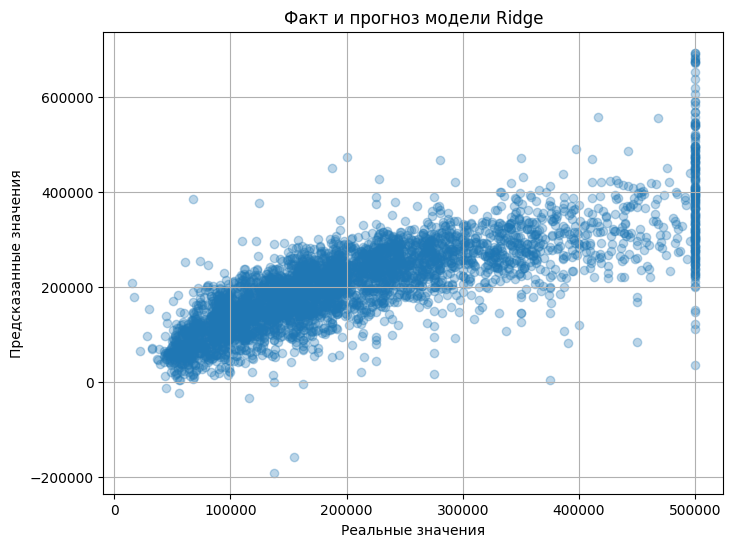

In [25]:
import matplotlib.pyplot as plt


best_model = ridge_best


prediction = best_model.predict(
    X_test_scaled
)


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction,
    alpha=0.3
)


plt.xlabel(
    "Реальные значения"
)

plt.ylabel(
    "Предсказанные значения"
)


plt.title(
    "Факт и прогноз модели Ridge"
)


plt.grid()

plt.show()

На графике отображается соответствие между фактической стоимостью жилья и значениями, предсказанными моделью.

Чем ближе точки располагаются к диагональной зависимости, тем точнее работает модель.

Отклонение точек от диагонали показывает величину ошибки прогнозирования.

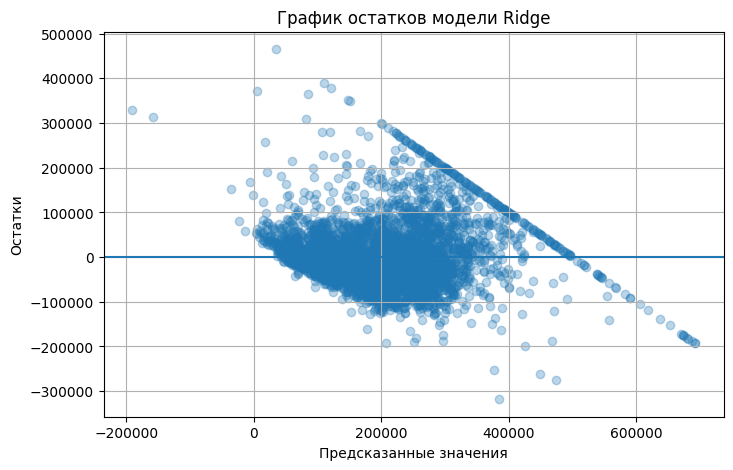

In [26]:
residuals = y_test - prediction


plt.figure(figsize=(8,5))

plt.scatter(
    prediction,
    residuals,
    alpha=0.3
)


plt.axhline(
    0
)


plt.xlabel(
    "Предсказанные значения"
)

plt.ylabel(
    "Остатки"
)


plt.title(
    "График остатков модели Ridge"
)


plt.grid()

plt.show()

График остатков позволяет проверить наличие систематических ошибок модели.

В случае хорошего качества модели остатки должны быть распределены случайным образом вокруг нулевой линии.

Наличие выраженного тренда может свидетельствовать о недостаточной сложности модели или нарушении предположений линейной регрессии.

# Метод главных компонент PCA

Метод главных компонент используется для преобразования исходного пространства признаков в новое пространство независимых компонент.

Основные задачи PCA:

- устранение коррелированных признаков;
- снижение размерности данных;
- уменьшение влияния мультиколлинеарности.

Перед применением PCA обязательно выполняется стандартизация признаков.

Перед применением PCA проверяется гипотеза: если признаки содержат мультиколлинеарность, то переход к главным компонентам может сделать модель устойчивее. Обратная сторона PCA — потеря прямой интерпретируемости исходных признаков, так как новые компоненты являются комбинациями исходных переменных.

In [27]:
from sklearn.decomposition import PCA


pca_full = PCA()


X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)


explained_variance = (
    pca_full
    .explained_variance_ratio_
)


explained_variance

array([0.3261906 , 0.18813371, 0.1285648 , 0.08974573, 0.08339944,
       0.08118002, 0.0478801 , 0.03470963, 0.01192088, 0.00487438,
       0.00219501, 0.00120571])

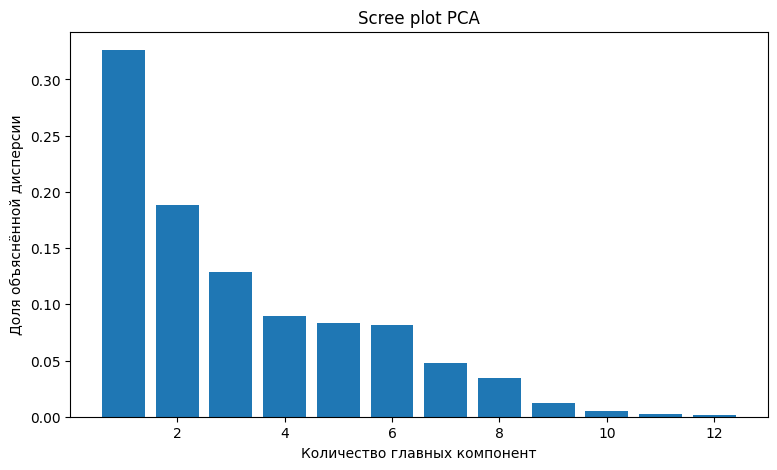

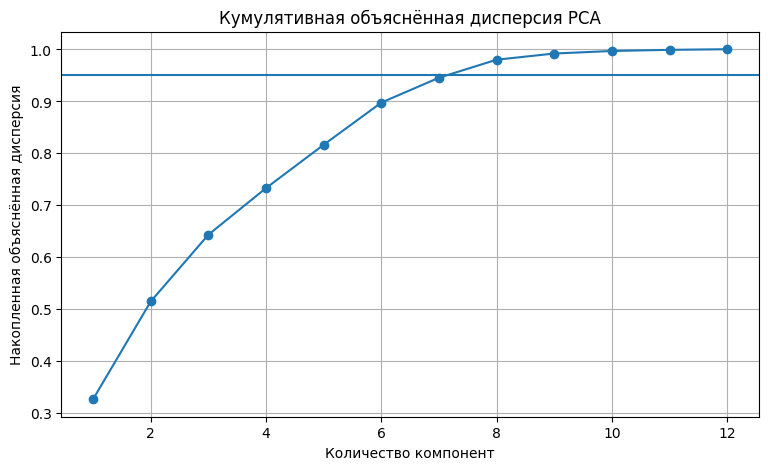

In [28]:
# Scree plot и накопленная объяснённая дисперсия PCA

fig, ax = plt.subplots(figsize=(9,5))

ax.bar(
    range(1, len(explained_variance)+1),
    explained_variance
)

ax.set_xlabel('Количество главных компонент')
ax.set_ylabel('Доля объяснённой дисперсии')
ax.set_title('Scree plot PCA')

plt.show()

plt.figure(figsize=(9,5))
plt.plot(
    range(1, len(explained_variance)+1),
    np.cumsum(explained_variance),
    marker='o'
)

plt.axhline(0.95)
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.title('Кумулятивная объяснённая дисперсия PCA')
plt.grid()
plt.show()

Построенный scree plot показывает вклад каждой главной компоненты в сохранение информации.

Первые компоненты объясняют большую часть дисперсии, а последующие дают всё меньший прирост. Поэтому выбор количества компонент выполняется не по максимальному числу признаков, а по порогу сохранённой информации.

График показывает долю информации, сохраняемую при выборе различного количества главных компонент.

Количество компонент выбирается таким образом, чтобы сохранить большую часть исходной информации.

В данной работе будет выбрано число компонент, обеспечивающее сохранение около 95% дисперсии.

In [29]:
cumulative_variance = np.cumsum(
    explained_variance
)


n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1


n_components

np.int64(8)

Автоматически выбрано количество главных компонент, которое сохраняет не менее 95% исходной информации.

Это позволяет уменьшить размерность данных, сохранив основные закономерности исходного набора.

In [30]:
pca = PCA(
    n_components=n_components
)


X_train_pca = pca.fit_transform(
    X_train_scaled
)


X_test_pca = pca.transform(
    X_test_scaled
)


X_train_pca.shape

(16512, 8)

После применения PCA количество признаков уменьшилось.

Новые признаки представляют собой главные компоненты — линейные комбинации исходных признаков.

Так как компоненты PCA ортогональны, проблема мультиколлинеарности между ними отсутствует.

In [31]:
linear_pca = LinearRegression()


linear_pca.fit(
    X_train_pca,
    y_train
)


linear_pca_results = evaluate_model(
    linear_pca,
    X_test_pca,
    y_test
)


linear_pca_results

(np.float64(73398.07160277285), 0.5888858360664103, 29.886325017635624)

In [32]:
ridge_pca_grid = GridSearchCV(
    Ridge(),
    {
        "alpha":[0.01,0.1,1,10,100]
    },
    cv=5,
    scoring="neg_root_mean_squared_error"
)


ridge_pca_grid.fit(
    X_train_pca,
    y_train
)


ridge_pca_best = ridge_pca_grid.best_estimator_


ridge_pca_results = evaluate_model(
    ridge_pca_best,
    X_test_pca,
    y_test
)


ridge_pca_results

(np.float64(73396.43502224392), 0.5889041693528334, 29.88856800541488)

После обучения Ridge на главных компонентах проверяется оптимальное значение `alpha`.

Так как PCA изменяет пространство признаков, параметры регуляризации необходимо подбирать заново. Значение, найденное GridSearchCV, используется для итогового сравнения модели после снижения размерности.

In [33]:
lasso_pca_grid = GridSearchCV(
    Lasso(max_iter=10000),
    {
        "alpha":[0.001,0.01,0.1,1,10]
    },
    cv=5,
    scoring="neg_root_mean_squared_error"
)


lasso_pca_grid.fit(
    X_train_pca,
    y_train
)


lasso_pca_best = lasso_pca_grid.best_estimator_


lasso_pca_results = evaluate_model(
    lasso_pca_best,
    X_test_pca,
    y_test
)


lasso_pca_results

(np.float64(73396.97465323686), 0.5888981243489657, 29.887071083838855)

После обучения Lasso на данных после PCA аналогично анализируется выбранный параметр регуляризации.

Сравнение моделей до и после PCA позволяет оценить, насколько уменьшение размерности влияет на качество прогноза.

# Сравнение моделей до и после PCA

На данном этапе выполняется итоговое сравнение качества всех построенных моделей.

Это позволяет определить:

- влияние PCA на качество прогнозирования;
- изменение ошибки моделей;
- эффективность устранения мультиколлинеарности.

In [34]:
comparison = pd.DataFrame(
    [
        ["Linear Regression", *linear_results],
        ["Ridge", *ridge_results],
        ["Lasso", *lasso_results],
        ["Linear PCA", *linear_pca_results],
        ["Ridge PCA", *ridge_pca_results],
        ["Lasso PCA", *lasso_pca_results]
    ],
    columns=[
        "Model",
        "RMSE",
        "R2",
        "MAPE"
    ]
)


comparison.sort_values(
    "RMSE"
)

,Model,RMSE,R2,MAPE
1,Ridge,70031.305311,0.625736,29.156504
2,Lasso,70053.904216,0.625495,29.181561
0,Linear Regression,70060.521845,0.625424,29.190663
4,Ridge PCA,73396.435022,0.588904,29.888568
5,Lasso PCA,73396.974653,0.588898,29.887071
3,Linear PCA,73398.071603,0.588886,29.886325


# Заключение

В работе была решена задача прогнозирования стоимости жилья в Калифорнии с использованием моделей линейной регрессии. Были построены три модели: Linear Regression, Ridge и Lasso, а затем выполнено повторное обучение этих моделей после применения PCA.

В процессе подготовки данных были обработаны пропуски в признаке `total_bedrooms`. Для заполнения использована медиана, так как она менее чувствительна к выбросам, чем среднее значение. Категориальный признак `ocean_proximity` преобразован методом One-Hot Encoding с параметром `drop_first=True`, что позволило избежать избыточного представления категорий.

Корреляционный анализ показал, что наибольшую связь с целевой переменной имеет признак `median_income` (коэффициент корреляции около 0.69). Это является умеренной положительной зависимостью: доход влияет на стоимость жилья, но не объясняет её полностью. Расчёт VIF подтвердил наличие выраженной мультиколлинеарности между связанными признаками (`total_rooms`, `total_bedrooms`, `households`), поэтому была проверена эффективность PCA.

До применения PCA лучшую точность показала модель **Ridge Regression**:
- RMSE ≈ **70031.31**;
- R² ≈ **0.6257**;
- MAPE ≈ **29.16%**.

После применения PCA количество признаков было уменьшено до **8 главных компонент**, которые сохраняют не менее 95% исходной дисперсии. Это сделало пространство признаков менее зависимым, однако качество моделей немного снизилось. Такое поведение является ожидаемым: PCA удаляет часть информации вместе с шумом и избыточностью признаков.

Таким образом, PCA не является способом гарантированного повышения точности. В данной задаче его преимущество заключается в уменьшении размерности и снижении влияния мультиколлинеарности. Для максимального качества прогноза на исходных признаках наиболее эффективной оказалась Ridge Regression.

# Источники

1. Kaggle. California Housing Prices Dataset: https://www.kaggle.com/datasets/camnugent/california-housing-prices
2. Scikit-learn Documentation: https://scikit-learn.org/
3. Statsmodels Documentation: https://www.statsmodels.org/
4. James G., Witten D., Hastie T., Tibshirani R. *An Introduction to Statistical Learning.*
5. Géron A. *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow.*

# Приложение

Полный листинг программного кода представлен непосредственно в ячейках данного Jupyter Notebook. Отдельное дублирование кода не выполняется, так как весь используемый код доступен в основной части работы.